# Calculus for ML: Derivatives and Gradients

**Goal:** Understand derivatives as rates of change, and gradients as the direction of steepest ascent.

**Reference:** Mathematics for ML - Chapter 5.1

## Derivative

The derivative of $f(x)$ at point $x$ is the **instantaneous rate of change**:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**Geometric meaning:** the slope of the tangent line at $x$.

**Why it matters for ML:**
- Tells us how loss changes when we nudge a parameter
- Direction of steepest descent = negative of gradient
- Backpropagation = chain rule applied to derivatives

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 

## Numerical Derivative

Instead of computing the limit analytically, we approximate it with a small $h$:

$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$

This is called the **central difference**. More accurate than forward difference.

In [4]:
def numerical_derivative(f , x , h=1e-5):
  return (f(x + h) - f(x - h)) / (2 * h)

f = lambda x : x**2

for x in [0,1,2,3]:
  approx = numerical_derivative(f,x)
  exact = 2 * x 
  print(f"x={x}: approx={approx:.6f}, exact={exact}")

x=0: approx=0.000000, exact=0
x=1: approx=2.000000, exact=2
x=2: approx=4.000000, exact=4
x=3: approx=6.000000, exact=6


## Partial Derivatives

For a function of multiple variables $f(x, y)$, the **partial derivative** with respect to $x$ treats $y$ as constant:

$$\frac{\partial f}{\partial x} = \lim_{h \to 0} \frac{f(x+h, y) - f(x, y)}{h}$$

**Gradient** is the vector of all partial derivatives:

$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \end{bmatrix}$$

**Geometric meaning:** points in the direction of steepest ascent.

In [6]:
def numerical_gradient(f, x, h=1e-5):
    """Gradient of f at point x (x is a vector)."""
    x = np.array(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy()
        x_minus = x.copy()
        x_plus[i] += h
        x_minus[i] -= h
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * h)
    return grad


# Test with f(x, y) = x^2 + 3y^2
# Gradient: [2x, 6y]
f = lambda v: v[0] ** 2 + 3 * v[1] ** 2

for point in [[1, 1], [2, 3], [0, -1]]:
    approx = numerical_gradient(f, point)
    exact = [2 * point[0], 6 * point[1]]
    print(f"At {point}: approx={approx}, exact={exact}")

At [1, 1]: approx=[2. 6.], exact=[2, 6]
At [2, 3]: approx=[ 4. 18.], exact=[4, 18]
At [0, -1]: approx=[ 0. -6.], exact=[0, -6]


## Gradient Descent

To **minimize** a function, we move in the direction **opposite** to the gradient:

$$x_{t+1} = x_t - \eta \nabla f(x_t)$$

- $\eta$ is the **learning rate** (step size)
- $\nabla f$ points to steepest ascent, so $-\nabla f$ points downhill

**This is the core of ML training.**

In [9]:
def gradient_descent(f, grad_f, x0, lr=0.1, n_steps=50):
    """Minimize f starting from x0."""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    for _ in range(n_steps):
        x = x - lr * grad_f(x)
        history.append(x.copy())
    return np.array(history)


# Minimize f(x, y) = x^2 + 3y^2
# Minimum at (0, 0)
f = lambda v: v[0] ** 2 + 3 * v[1] ** 2
grad_f = lambda v: np.array([2 * v[0], 6 * v[1]])

history = gradient_descent(f, grad_f, x0=[3, 3], lr=0.1, n_steps=30)
print("Start:", history[0])
print("End:  ", history[-1])
print("Final f value:", f(history[-1]))

Start: [3. 3.]
End:   [3.71382012e-03 3.45876451e-12]
Final f value: 1.3792459867793008e-05


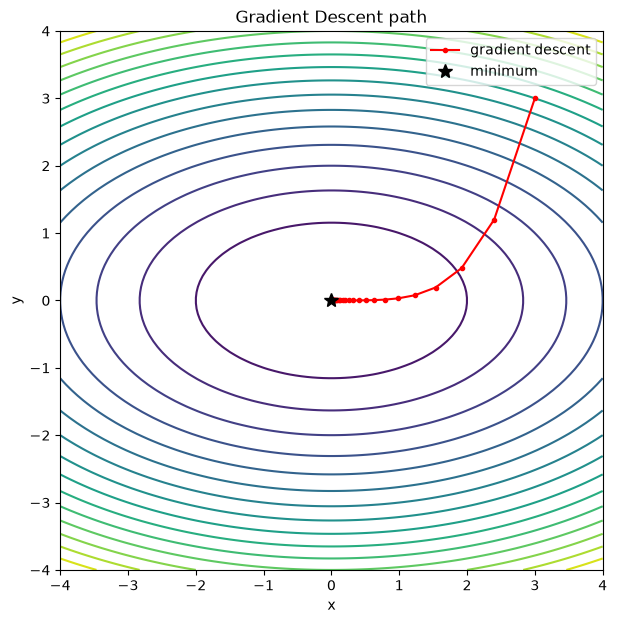

In [13]:
# Create a contour plot of f(x, y) = x^2 + 3y^2
x_vals = np.linspace(-4, 4, 100)
y_vals = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X ** 2 + 3 * Y ** 2

fig, ax = plt.subplots(figsize=(7, 7))
ax.contour(X, Y, Z, levels=20, cmap='viridis')

# Plot the descent path
ax.plot(history[:, 0], history[:, 1], 'r.-', label='gradient descent')
ax.plot(0, 0, 'k*', markersize=10, label='minimum')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gradient Descent path')
ax.legend()
plt.show()

## Key Takeaways

- **Derivative** = rate of change = slope of tangent
- **Partial derivative** = derivative w.r.t. one variable, others held constant
- **Gradient** = vector of partial derivatives; points uphill
- **Gradient descent** = `x = x - lr * gradient` to minimize
- **Learning rate** matters: too big → diverge, too small → slow

## Connection to ML

- Training a neural network = gradient descent on loss
- Backpropagation = chain rule on derivatives
- Gradient tells us how to update each parameter